In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn import svm
import matplotlib.pyplot as plt
from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import average_precision_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

ImportError: ignored

In [ ]:
## load dataset
df=pd.read_csv('https://raw.githubusercontent.com/mahiealam/diabacare-cloud-diabetes-prediction/refs/heads/main/data/MainDiabetes_2.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,BMI,Age,Outcome
0,6,148,72,33.6,50,1
1,1,85,66,26.6,31,0
2,8,183,64,23.3,32,1
3,1,89,66,28.1,21,0
4,0,137,40,43.1,33,1


In [ ]:
# statistic of dataset
diabetes=df[df['Outcome']==1].shape
non_diabetes=df[df['Outcome']==0].shape
print("Has Diabeties {}, Does not have Diabetes {}".format(diabetes,non_diabetes))
df.describe()

Has Diabeties (268, 6), Does not have Diabetes (500, 6)


,Pregnancies,Glucose,BloodPressure,BMI,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,31.992578,33.240885,0.348958
std,3.369578,31.972618,19.355807,7.884160,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,27.300000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,32.000000,29.000000,0.000000
75%,6.000000,140.250000,80.000000,36.600000,41.000000,1.000000
max,17.000000,199.000000,122.000000,67.100000,81.000000,1.000000


In [ ]:
# x-axis range , y-axis abundance
histo = df.hist(figsize = (20,20))

NameError: ignored

In [ ]:
df ['Outcome'].value_counts()

0    500
1    268
Name: Outcome, dtype: int64

In [ ]:
df.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,BMI,Age
Outcome,,,,,
0,3.298000,109.980000,68.184000,30.304200,31.190000
1,4.865672,141.257463,70.824627,35.142537,37.067164


In [ ]:
df_copy=df.copy(deep=True)

In [ ]:
df_copy=df_copy[(df_copy['BloodPressure']!=0) & (df_copy['BMI']!=0) & (df_copy['Glucose']!=0)]

In [ ]:
## split dataset on outcome from 70% to 30%
X=df_copy.drop('Outcome',axis=1)
y=df_copy['Outcome']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=10)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(506, 5)
(218, 5)
(506,)
(218,)


In [ ]:
# 1. decision tree
d_tree=tree.DecisionTreeClassifier()
d_tree.fit(X_train,y_train)
predicted_tree=d_tree.predict(X_test)
accuracy_tree=metrics.accuracy_score(y_test,predicted_tree)
cm_dt=metrics.confusion_matrix(y_test,predicted_tree)

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


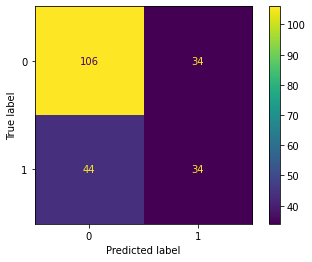

In [ ]:
plot_confusion_matrix(d_tree, X_test, y_test)
plt.show()

In [ ]:
print("Confusion Matrix : \n {}  \n Accuracy :  {} ".format(cm_dt,accuracy_tree))

Confusion Matrix : 
 [[106  34]
 [ 44  34]]  
 Accuracy :  0.6422018348623854 


In [ ]:
average_precision = average_precision_score(y_test, predicted_tree)
print("Average precision : {}" .format (average_precision))

Average precision : 0.41978358033403906


In [ ]:
print(classification_report(y_test, predicted_tree))

              precision    recall  f1-score   support

           0       0.71      0.76      0.73       140
           1       0.50      0.44      0.47        78

    accuracy                           0.64       218
   macro avg       0.60      0.60      0.60       218
weighted avg       0.63      0.64      0.64       218



In [ ]:
# 2. KNN Implementation
knn=KNeighborsClassifier(n_neighbors=11)
knn.fit(X_train,y_train)
predicted_knn=knn.predict(X_test)
cm_knn=metrics.confusion_matrix(y_test,predicted_knn)
accuracy_knn=metrics.accuracy_score(y_test,predicted_knn)

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


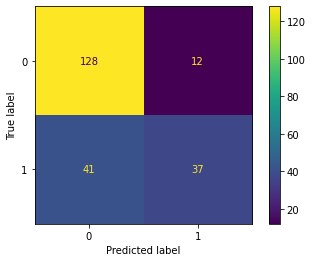

In [ ]:
plot_confusion_matrix(knn, X_test, y_test)
plt.show()

In [ ]:
print("Confusion Matrix : \n {}  \n Accuracy :  {} ".format(cm_knn,accuracy_knn))

Confusion Matrix : 
 [[128  12]
 [ 41  37]]  
 Accuracy :  0.7568807339449541 


In [ ]:
# k=3 (accuracy  0.7385321100917431) k=5 ( Accuracy :0.7522935779816514 )
# k=11 (Accuracy :  0.7706422018348624) k=13 ( Accuracy :  0.7614678899082569 )
average_precision = average_precision_score(y_test, predicted_knn)
print("Average Precision : {}".format (average_precision))

Average Precision : 0.5462628241134139


In [ ]:
print(classification_report (y_test, predicted_knn))

              precision    recall  f1-score   support

           0       0.76      0.91      0.83       140
           1       0.76      0.47      0.58        78

    accuracy                           0.76       218
   macro avg       0.76      0.69      0.71       218
weighted avg       0.76      0.76      0.74       218



In [ ]:
# 3. Logistic regression
logisticRegr= LogisticRegression()
logisticRegr.fit(X_train,y_train)
predict_lg = logisticRegr.predict(X_test)
accuarcy_lg=metrics.accuracy_score(y_test,predict_lg)
cm_lg=metrics.confusion_matrix(y_test,predict_lg)

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


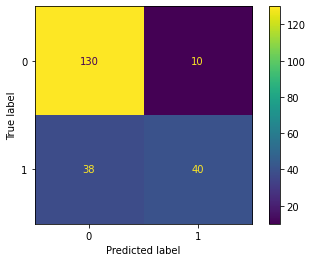

In [ ]:
plot_confusion_matrix(logisticRegr, X_test, y_test)
plt.show()

In [ ]:
print("Confusion Matrix : \n {}  \n Accuracy :  {} ".format(cm_lg,accuarcy_lg))

Confusion Matrix : 
 [[130  10]
 [ 38  40]]  
 Accuracy :  0.7798165137614679 


In [ ]:
average_precision = average_precision_score(y_test, predict_lg)
print("Average Precision : {}".format (average_precision))

Average Precision : 0.5845683368619149


In [ ]:
print(classification_report (y_test, predict_lg))

              precision    recall  f1-score   support

           0       0.77      0.93      0.84       140
           1       0.80      0.51      0.62        78

    accuracy                           0.78       218
   macro avg       0.79      0.72      0.73       218
weighted avg       0.78      0.78      0.77       218



In [ ]:
#4. Naive Byes
naive = GaussianNB()
naive.fit(X_train,y_train)
predicted_naive=naive.predict(X_test)
cm_naive=metrics.confusion_matrix(y_test,predicted_naive)
accuracy_naive=metrics.accuracy_score(y_test,predicted_naive)

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


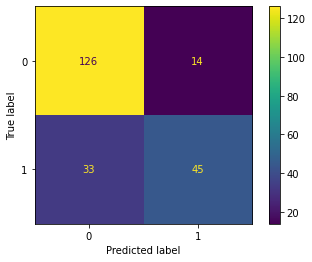

In [ ]:
plot_confusion_matrix(naive, X_test, y_test)
plt.show()

In [ ]:
print("Confusion Matrix : \n {}  \n Accuracy : \n {} ".format(cm_naive,accuracy_naive))

Confusion Matrix : 
 [[126  14]
 [ 33  45]]  
 Accuracy : 
 0.7844036697247706 


In [ ]:
average_precision = average_precision_score(y_test, predicted_naive)
print("Average Precision : {}" .format (average_precision))

Average Precision : 0.5914022224082868


In [ ]:
print(classification_report (y_test, predicted_naive))

              precision    recall  f1-score   support

           0       0.79      0.90      0.84       140
           1       0.76      0.58      0.66        78

    accuracy                           0.78       218
   macro avg       0.78      0.74      0.75       218
weighted avg       0.78      0.78      0.78       218



In [ ]:
#5. Random Forest
from sklearn import metrics

rfm = RandomForestClassifier(n_estimators=70, oob_score=True, n_jobs=-1, random_state=101, max_features = None, min_samples_leaf = 30)
rfm = rfm.fit(X_train, y_train)
pred_forest=rfm.predict(X_test)
accuracy_forest=metrics.accuracy_score(y_test,pred_forest)
cm_rf=metrics.confusion_matrix(y_test,pred_forest)


/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


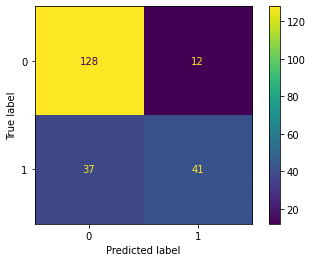

In [ ]:
plot_confusion_matrix(rfm, X_test, y_test)
plt.show()

In [ ]:
print("Confusion Matrix : \n {}  \n Accuracy :  {} ".format(cm_rf,accuracy_forest))

Confusion Matrix : 
 [[128  12]
 [ 37  41]]  
 Accuracy :  0.7752293577981652 


In [ ]:
average_precision = average_precision_score(y_test, pred_forest)
print("Average Precision : {}" .format (average_precision))

Average Precision : 0.5763527338739387


In [ ]:
print(classification_report (y_test, pred_forest))

              precision    recall  f1-score   support

           0       0.78      0.91      0.84       140
           1       0.77      0.53      0.63        78

    accuracy                           0.78       218
   macro avg       0.77      0.72      0.73       218
weighted avg       0.77      0.78      0.76       218



In [ ]:
# 6. SVM
#Data Standardization
scaler = StandardScaler()
scaler.fit(X)
standardized_data = scaler.transform(X)
print(standardized_data)

[[ 0.63502182  0.84993279 -0.03237751  0.16456174  1.41607523]
 [-0.85286102 -1.20026207 -0.51737031 -0.85226209 -0.19994691]
 [ 1.23017496  1.98892994 -0.67903458 -1.33162189 -0.11489311]
 ...
 [ 0.33744525 -0.02872215 -0.03237751 -0.9103663  -0.28500071]
 [-0.85286102  0.13399173 -1.00236311 -0.34385017  1.16091384]
 [-0.85286102 -0.93991986 -0.19404178 -0.30027201 -0.88037728]]


In [ ]:
X = standardized_data
Y = df['Outcome']
print(X)

[[ 0.63502182  0.84993279 -0.03237751  0.16456174  1.41607523]
 [-0.85286102 -1.20026207 -0.51737031 -0.85226209 -0.19994691]
 [ 1.23017496  1.98892994 -0.67903458 -1.33162189 -0.11489311]
 ...
 [ 0.33744525 -0.02872215 -0.03237751 -0.9103663  -0.28500071]
 [-0.85286102  0.13399173 -1.00236311 -0.34385017  1.16091384]
 [-0.85286102 -0.93991986 -0.19404178 -0.30027201 -0.88037728]]


In [ ]:
print(Y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


In [ ]:
SupportV = svm.SVC(kernel='linear')
# Training SVM
SupportV = SupportV.fit(X_train, y_train)
# Accuracy score of training data
SupportV_pred = SupportV.predict(X_train)
accuracy_SupportV = accuracy_score(SupportV_pred, y_train)
cm_SupportV=metrics.confusion_matrix(y_train, SupportV_pred)

/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


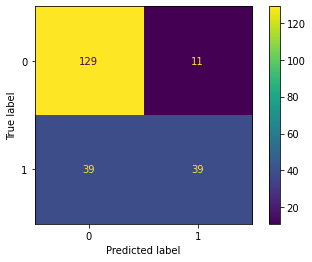

In [ ]:
plot_confusion_matrix(SupportV, X_test, y_test)
plt.show()

In [ ]:
print("Confusion Matrix : \n {}  \n Accuracy :  {} ".format(cm_SupportV,accuracy_SupportV))

Confusion Matrix : 
 [[292  43]
 [ 73  98]]  
 Accuracy :  0.7707509881422925 


In [ ]:
average_precision = average_precision_score(y_train, SupportV_pred)
print("Average Precision : {}" .format (average_precision))

Average Precision : 0.5425931909451067


In [ ]:
print(classification_report (y_train, SupportV_pred))

              precision    recall  f1-score   support

           0       0.80      0.87      0.83       335
           1       0.70      0.57      0.63       171

    accuracy                           0.77       506
   macro avg       0.75      0.72      0.73       506
weighted avg       0.76      0.77      0.76       506

